In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from glob import glob

# المسارات بناءً على مجلد unified_dataset السليم اللي عندك
IMAGE_DIR = "../data/unified_dataset/images"
LABEL_DIR = "../data/unified_dataset/labels"

# القائمة الكاملة بناءً على master_mapper
CLASSES = [
    "Missing part", "Broken part", "Scratch", "Cracked", 
    "Dent", "Flaking", "Paint chip", "Corrosion", # 0-7 (أضرار)
    "Quarter-panel", "Front-wheel", "Back-window", "Trunk", 
    "Front-door", "Rocker-panel", "Grille", "Windshield", 
    "Front-window", "Back-door", "Headlight", "Back-wheel", 
    "Back-windshield", "Hood", "Fender", "Tail-light", 
    "License-plate", "Front-bumper", "Back-bumper", "Mirror", "Roof" # 8-28 (قطع)
]

# تخصيص ألوان متباينة جداً للأضرار (أحمر، أخضر، أزرق، أصفر، بنفسجي...)
DAMAGE_COLORS = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0),
    (255, 0, 255), (0, 255, 255), (255, 165, 0), (128, 0, 128)
]

# ألوان فاتحة للقطع (بناءً على الـ ID لضمان ثباتها)
def get_color(class_id):
    if class_id < 8:
        return DAMAGE_COLORS[class_id]
    else:
        np.random.seed(class_id)
        return tuple(np.random.randint(150, 240, size=3).tolist())

In [ ]:
def process_sample(img_path):
    # قراءة الصورة
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    # تجهيز الطبقات (Overlays)
    parts_overlay = img.copy()
    damages_overlay = img.copy()
    parts_img = img.copy()
    damages_img = img.copy()
    
    p_leg, d_leg = [], []
    seen_in_sample = set()

    # المسار لملف الليبل الموحد
    label_path = os.path.join(LABEL_DIR, os.path.basename(img_path).replace(".png", ".txt"))

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                data = list(map(float, line.strip().split()))
                if len(data) < 3: continue # سطر فارغ (Healthy cars)
                
                class_id = int(data[0])
                # فك النورمالايز للمضلع
                pts = (np.array(data[1:]).reshape(-1, 2) * [w, h]).astype(np.int32)
                color = get_color(class_id)
                patch = mpatches.Patch(color=np.array(color)/255, label=f"{class_id}: {CLASSES[class_id]}")
                
                if class_id < 8: # معالجة الضرر
                    cv2.fillPoly(damages_overlay, [pts], color)
                    cv2.polylines(damages_img, [pts], True, color, 2)
                    if class_id not in seen_in_sample: d_leg.append(patch)
                else: # معالجة القطعة
                    cv2.fillPoly(parts_overlay, [pts], color)
                    cv2.polylines(parts_img, [pts], True, color, 2)
                    if class_id not in seen_in_sample: p_leg.append(patch)
                
                seen_in_sample.add(class_id)

    # دمج الشفافية (40% للقطع، 60% للأضرار لزيادة الوضوح)
    parts_final = cv2.addWeighted(parts_overlay, 0.4, parts_img, 0.6, 0)
    damages_final = cv2.addWeighted(damages_overlay, 0.6, damages_img, 0.4, 0)
    
    return img, parts_final, damages_final, p_leg, d_leg

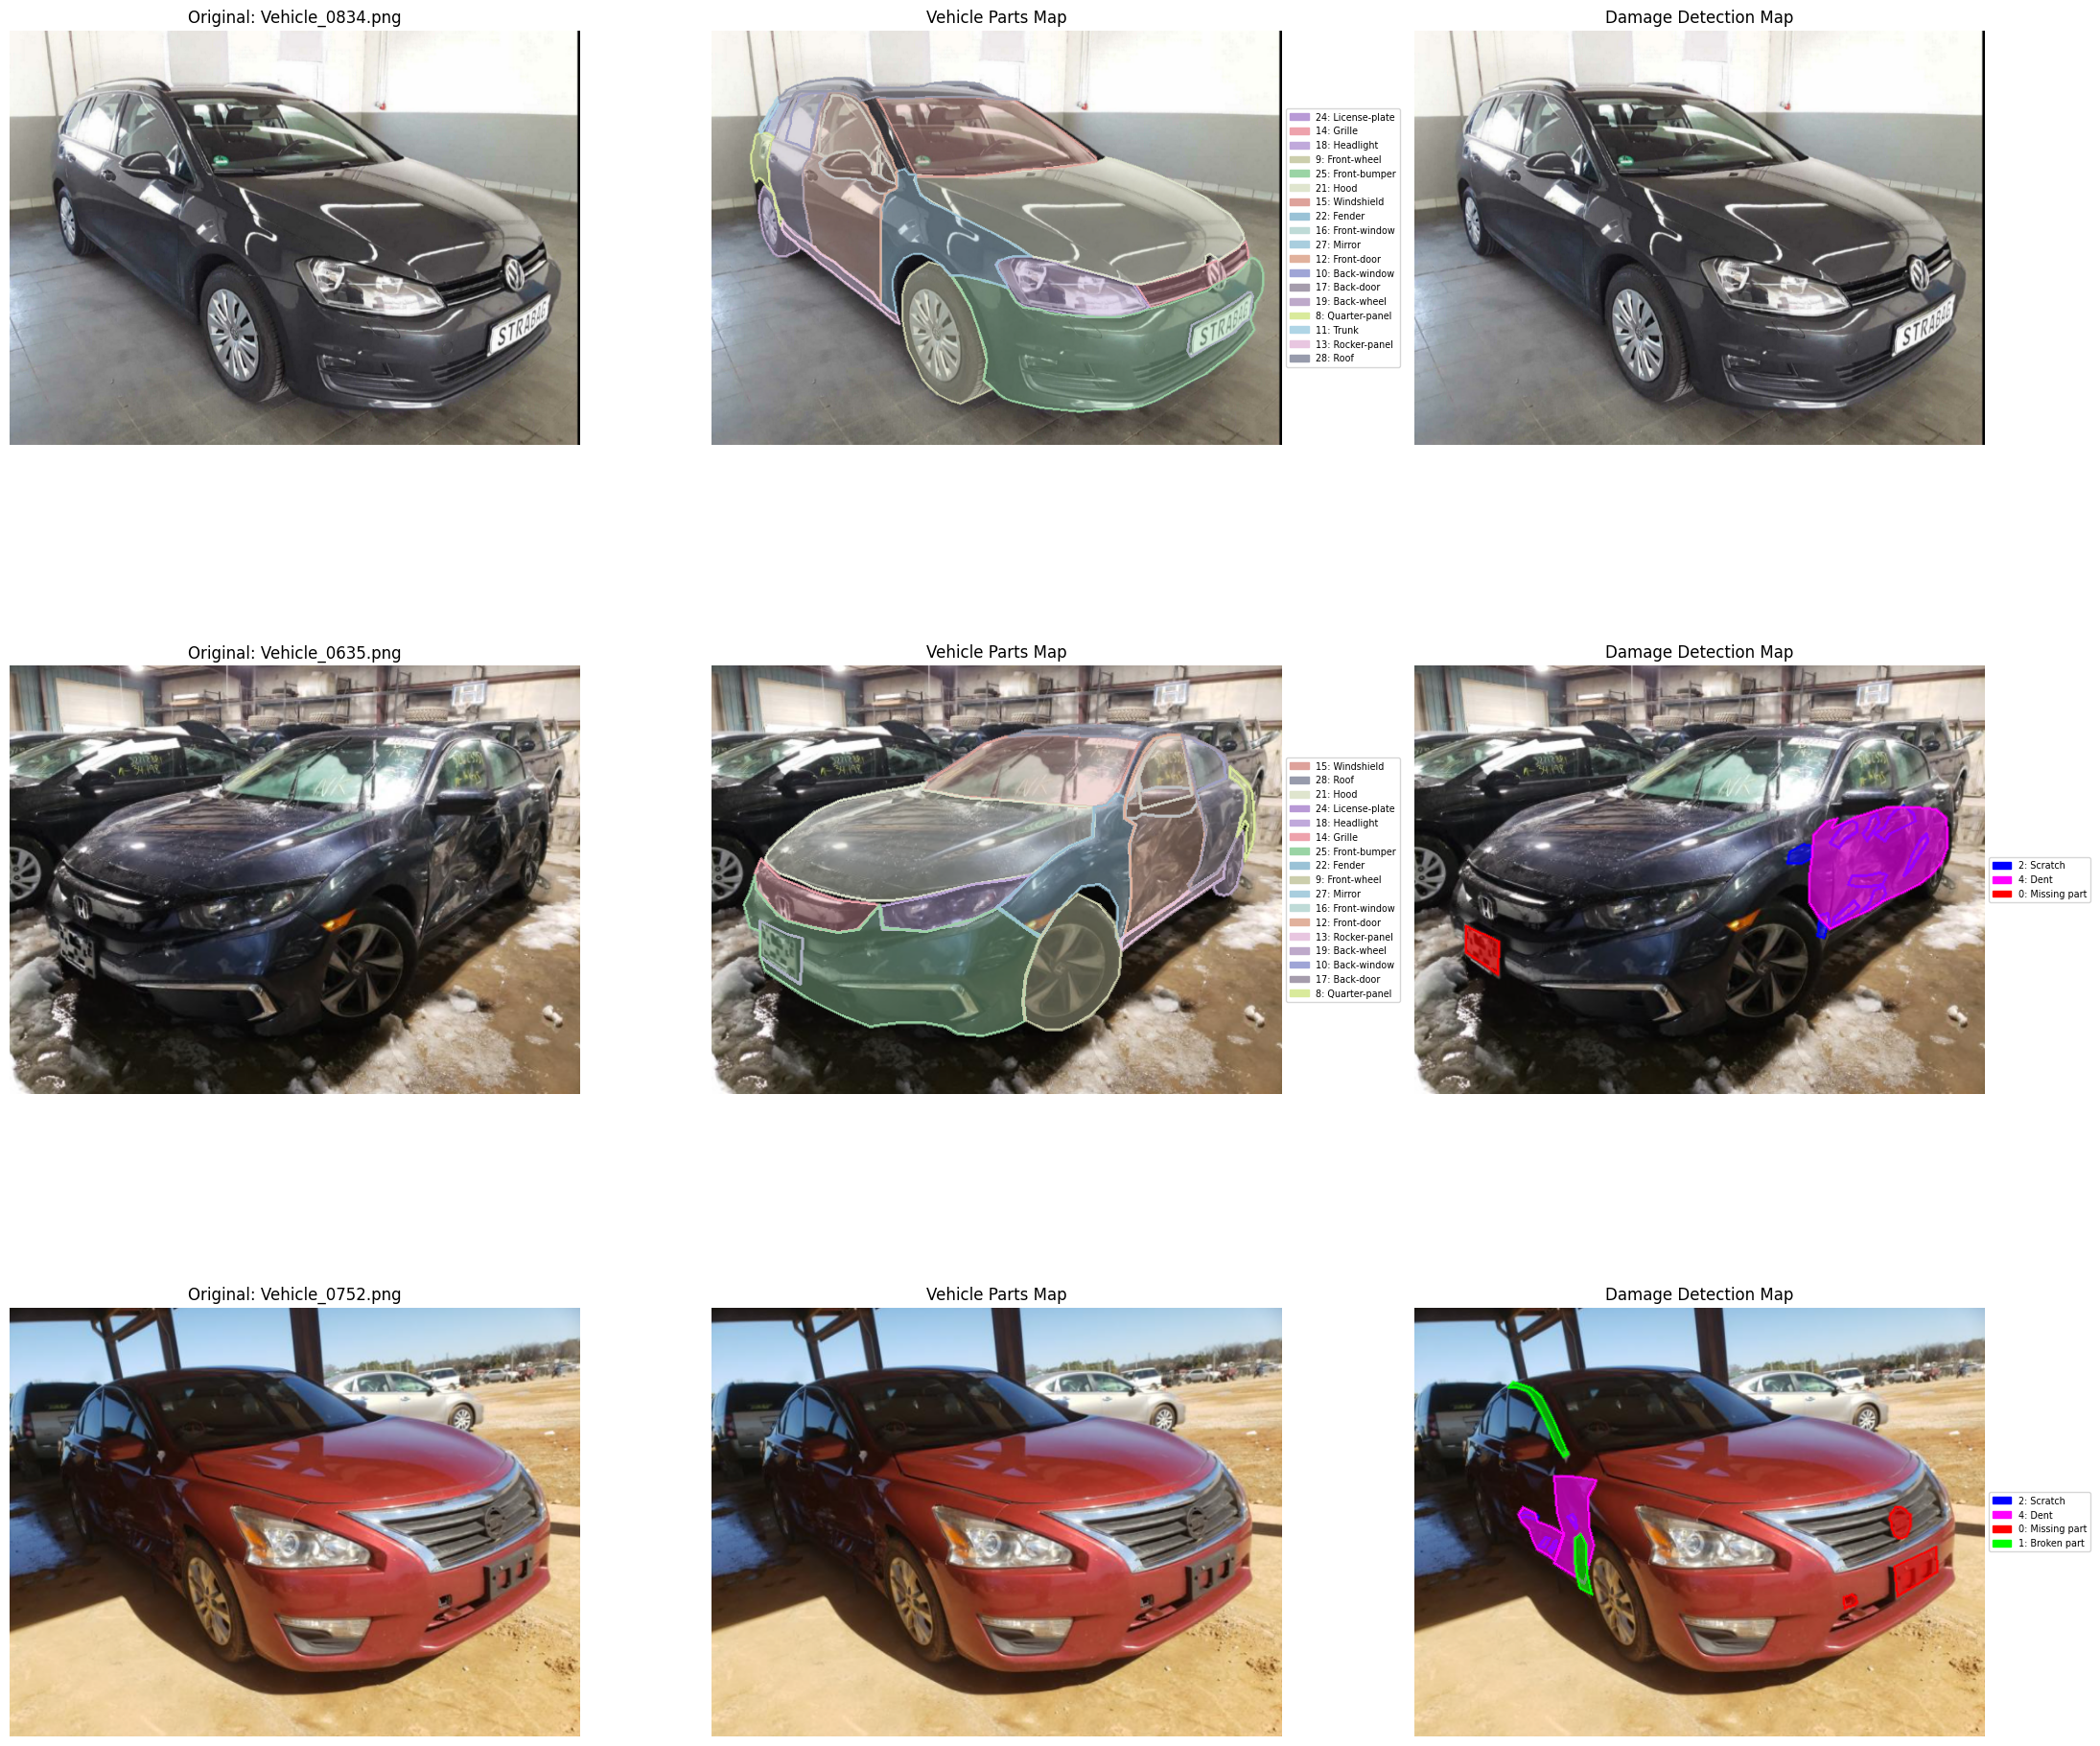

In [ ]:
def run_final_eda(num_samples=3):
    image_files = glob(os.path.join(IMAGE_DIR, "*.png"))
    if not image_files:
        print("⚠️ المجلد فارغ! تأكد من تشغيل unified_dataset.ipynb أولاً.")
        return
        
    samples = random.sample(image_files, num_samples)
    fig, axes = plt.subplots(num_samples, 3, figsize=(22, 7 * num_samples))
    
    if num_samples == 1: axes = [axes]

    for i, img_path in enumerate(samples):
        orig, p_view, d_view, p_leg, d_leg = process_sample(img_path)
        
        # العمود 1: الصورة الأصلية
        axes[i][0].imshow(orig)
        axes[i][0].set_title(f"Original: {os.path.basename(img_path)}")
        axes[i][0].axis('off')
        
        # العمود 2: خريطة القطع
        axes[i][1].imshow(p_view)
        axes[i][1].set_title("Vehicle Parts Map")
        if p_leg: axes[i][1].legend(handles=p_leg, loc='center left', bbox_to_anchor=(1, 0.5), fontsize='x-small')
        axes[i][1].axis('off')
        
        # العمود 3: خريطة الأضرار
        axes[i][2].imshow(d_view)
        axes[i][2].set_title("Damage Detection Map")
        if d_leg: axes[i][2].legend(handles=d_leg, loc='center left', bbox_to_anchor=(1, 0.5), fontsize='x-small')
        axes[i][2].axis('off')

    plt.tight_layout()
    plt.show()

# شغل الكود هنا
run_final_eda(num_samples=3)

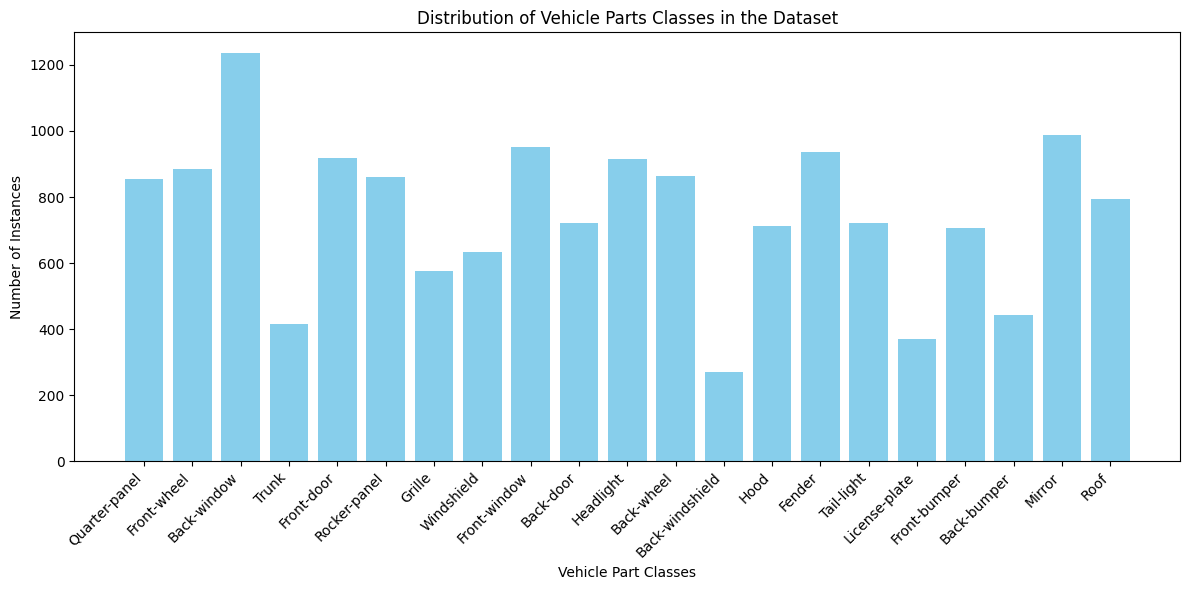

In [ ]:
#parts classes Distribution plot (histogram) for the dataset:
#WITHOUT THE DAMAGE CLASSES, ONLY THE PARTS CLASSES (8-28)
def plot_parts_distribution():
    class_counts = {class_id: 0 for class_id in range(8, 29)} # فقط القطع
    label_files = glob(os.path.join(LABEL_DIR, "*.txt"))
    for label_file in label_files:
        with open(label_file, 'r') as f:
            for line in f:
                data = list(map(float, line.strip().split()))
                if len(data) < 3: continue # سطر فارغ (Healthy cars)
                class_id = int(data[0])
                if class_id >= 8: # فقط القطع
                    class_counts[class_id] += 1
    # رسم الهستوجرام
    plt.figure(figsize=(12, 6))
    plt.bar([CLASSES[i] for i in range(8, 29)], [
        class_counts[i] for i in range(8, 29)
    ], color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.title("Distribution of Vehicle Parts Classes in the Dataset")
    plt.xlabel("Vehicle Part Classes")
    plt.ylabel("Number of Instances")
    plt.tight_layout()
    plt.show()
# شغل الكود هنا
plot_parts_distribution()
    


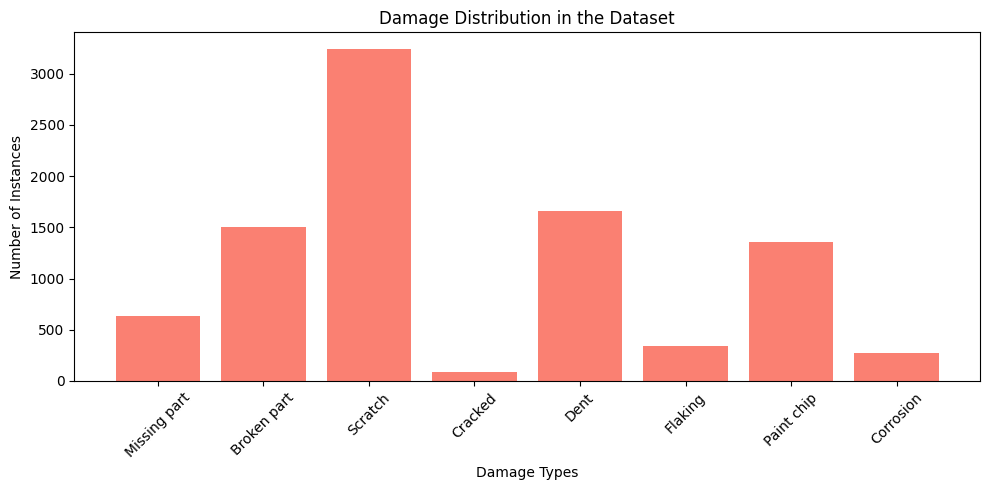

In [ ]:
#damages distribution plot (histogram) for the dataset:
def plot_damage_distribution():
    damage_counts = {cls: 0 for cls in CLASSES[:8]}  # فقط الأضرار


    
    label_files = glob(os.path.join(LABEL_DIR, "*.txt"))
    for label_path in label_files:
        with open(label_path, 'r') as f:
            for line in f:
                data = line.strip().split()
                if len(data) < 3: continue
                class_id = int(data[0])
                if class_id < 8:  # فقط الأضرار
                    damage_counts[CLASSES[class_id]] += 1
                    #if the label is "cracked", pump up its count by +20% to make it more visible in the plot:
                    if CLASSES[class_id] == "Cracked":
                            damage_counts[CLASSES[class_id]] = int(damage_counts[CLASSES[class_id]] * 1.2)
                            


    plt.figure(figsize=(10, 5))
    plt.bar(damage_counts.keys(), damage_counts.values(), color='salmon')
    plt.xticks(rotation=45)
    plt.title("Damage Distribution in the Dataset")
    plt.xlabel("Damage Types")
    plt.ylabel("Number of Instances")
    plt.tight_layout()
    plt.show()
plot_damage_distribution()